In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve, auc, average_precision_score, f1_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression

In [88]:
df = pd.read_csv("/Users/nicholascullen/Documents/Bank Customer Churn Prediction_revised-1.csv")

X = df.drop('churn', axis=1)
y = df['churn']

X = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

In [89]:
def evaluate_model(y_test, y_pred_prob, model_name):
    y_pred = (y_pred_prob >= 0.5).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    MR = (fp + fn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    f1 = f1_score(y_test, y_pred)
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = auc(recall_curve, precision_curve)
    
    plt.plot(recall_curve, precision_curve, label=model_name)
    
    return MR, recall, precision, f1, pr_auc

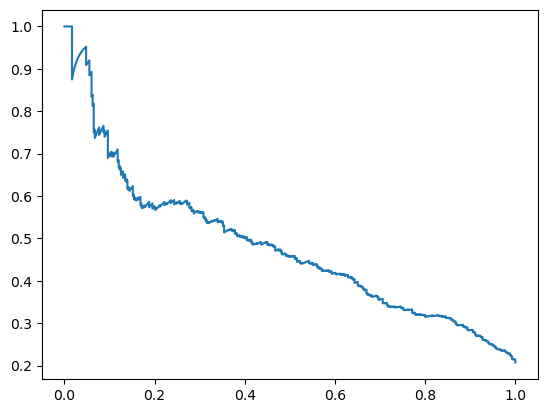

In [90]:
model1 = sm.Logit(y_train, X_train).fit(disp=0)
y_pred_prob1 = model1.predict(X_test)

metrics1 = evaluate_model(y_test, y_pred_prob1, "Model 1")

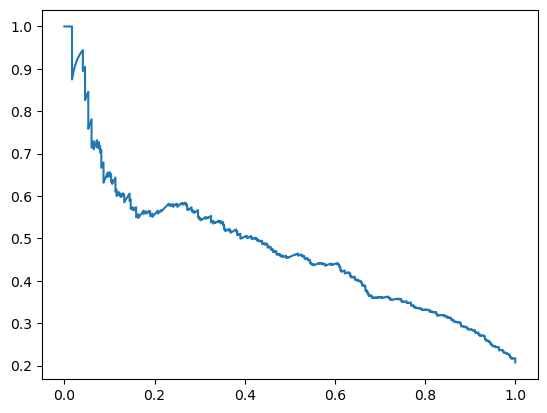

In [91]:
rus = RandomUnderSampler(random_state=1)
X_res, y_res = rus.fit_resample(X_train, y_train)

model2 = sm.Logit(y_res, X_res).fit(disp=0)
y_pred_prob2 = model2.predict(X_test)

metrics2 = evaluate_model(y_test, y_pred_prob2, "Model 2")

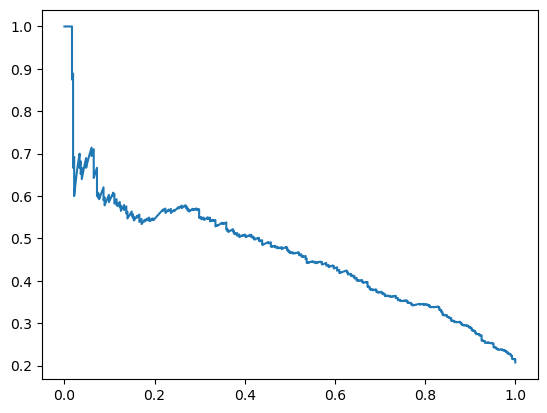

In [92]:
ros = RandomOverSampler(random_state=1)
X_res, y_res = ros.fit_resample(X_train, y_train)

model3 = sm.Logit(y_res, X_res).fit(disp=0)
y_pred_prob3 = model3.predict(X_test)

metrics3 = evaluate_model(y_test, y_pred_prob3, "Model 3")

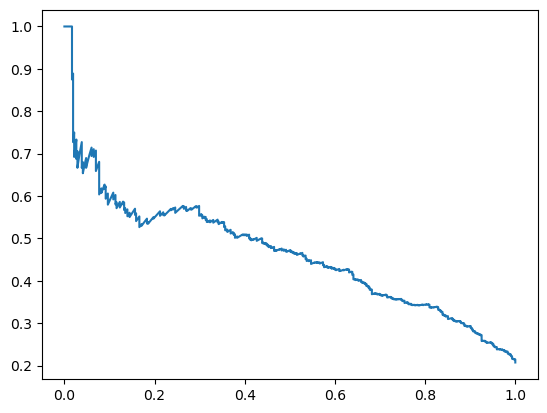

In [93]:
X_train_lr = X_train.drop('const', axis=1)
X_test_lr = X_test.drop('const', axis=1)

model4 = LogisticRegression(class_weight='balanced', max_iter=10000)
model4.fit(X_train_lr, y_train)

y_pred_prob4 = model4.predict_proba(X_test_lr)[:,1]

metrics4 = evaluate_model(y_test, y_pred_prob4, "Model 4")

In [94]:
results = pd.DataFrame({
    "Model": ["Model1", "Model2", "Model3", "Model4"],
    "MR": [metrics1[0], metrics2[0], metrics3[0], metrics4[0]],
    "Recall": [metrics1[1], metrics2[1], metrics3[1], metrics4[1]],
    "Precision": [metrics1[2], metrics2[2], metrics3[2], metrics4[2]],
    "F1": [metrics1[3], metrics2[3], metrics3[3], metrics4[3]],
    "AUC": [metrics1[4], metrics2[4], metrics3[4], metrics4[4]]
})

print(results)

    Model      MR    Recall  Precision        F1       AUC
0  Model1  0.1980  0.168675   0.578512  0.261194  0.480141
1  Model2  0.3000  0.672289   0.375505  0.481865  0.474729
2  Model3  0.2875  0.672289   0.388579  0.492498  0.463188
3  Model4  0.2890  0.672289   0.386963  0.491197  0.464302
